100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 6864/6864 [00:07<00:00, 921.23it/s]


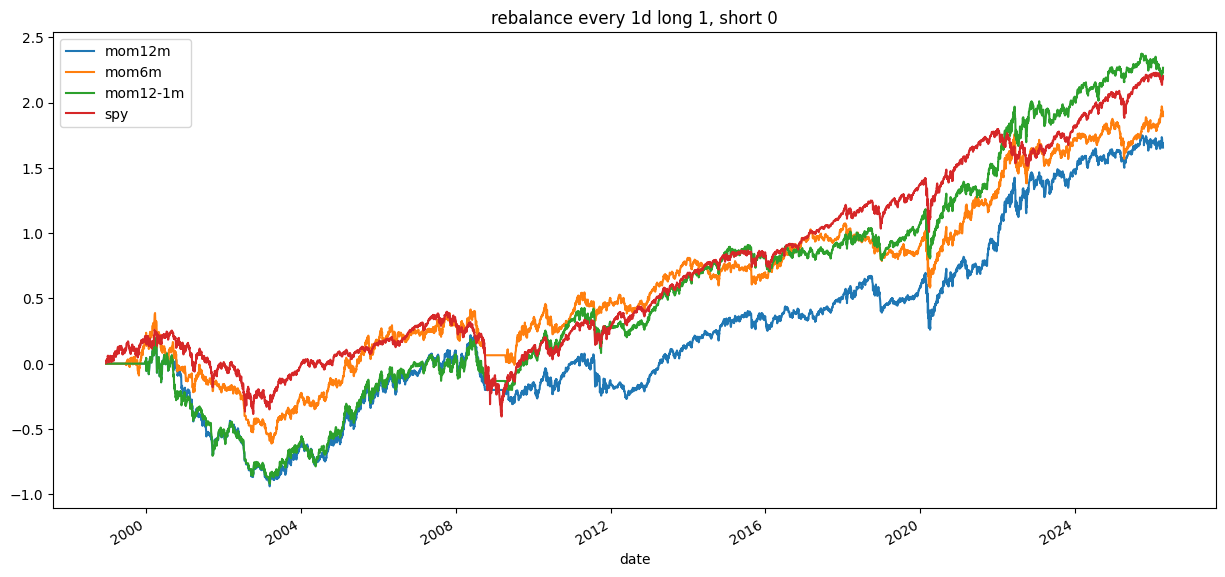

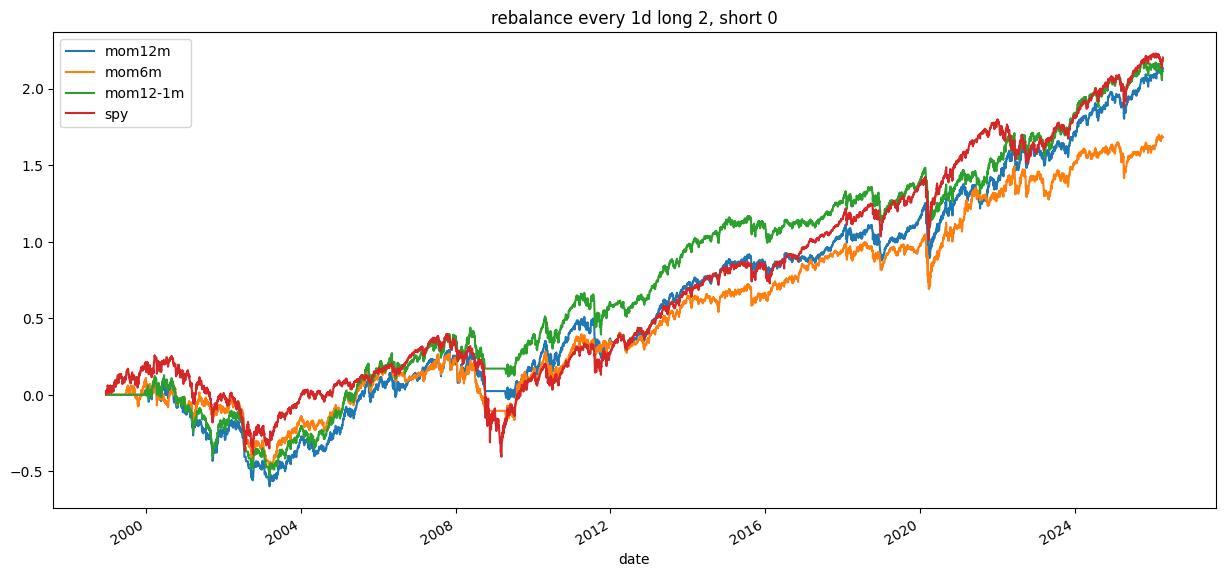

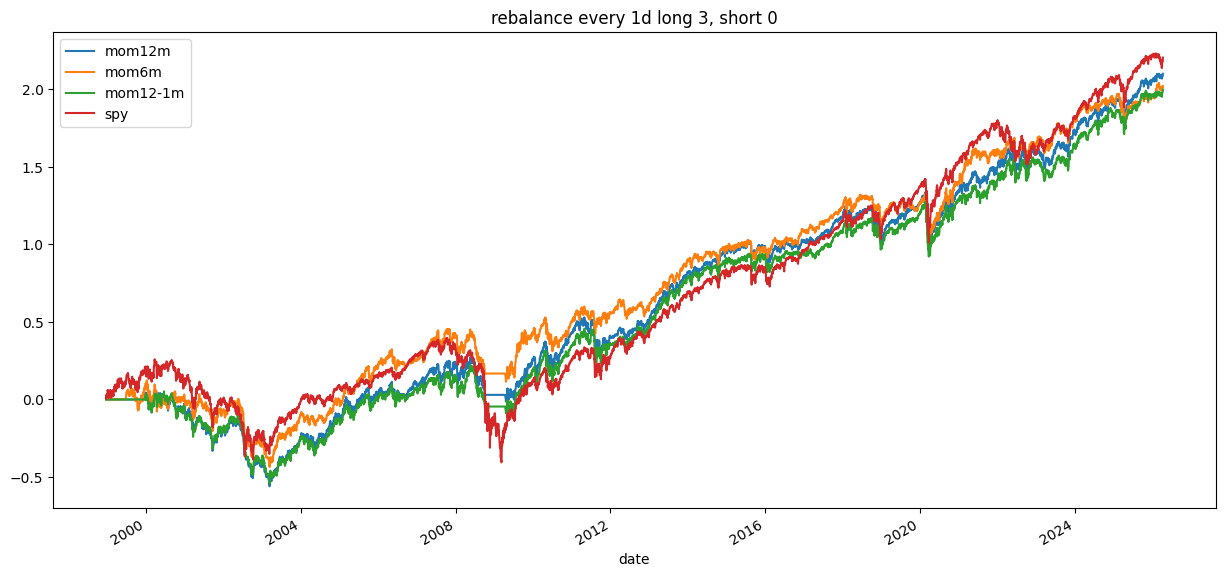

In [123]:
# derive spx membership

import polars as pl
import numpy as np
import pandas as pd
from typing import Callable, Literal
from tqdm import tqdm

sector_etfs = [
    "XLB",
    "XLC",
    "XLE",
    "XLF",
    "XLI",
    "XLK",
    "XLP",
    "XLRE",
    "XLU",
    "XLV",
    "XLY",
]


def zscore(window: int) -> Callable[[pl.Expr], pl.Expr]:
    def _zscore(val: pl.Expr) -> pl.Expr:
        return (val - val.rolling_mean(window)) / val.rolling_std(window)

    return _zscore


# yang-zhang variance estimation parameters
yz_k = 0.34
yz_win = 25

parameter_sets = [
    {"max_long": 1, "max_short": 0, "period": 1},
    {"max_long": 2, "max_short": 0, "period": 1},
    {"max_long": 3, "max_short": 0, "period": 1},
]

for param in parameter_sets:
    max_long = param["max_long"]
    max_short = param["max_short"]
    rebalance_period = param["period"]

    signals = {
        "mom12m": pl.col("mom12m"),
        "mom6m": pl.col("mom6m"),
        # "mom3m": pl.col("mom3m"),
        # "mom2m": pl.col("mom2m"),
        # "mom1m": pl.col("mom1m"),
        # "mom3+6+12m": pl.col("mom12m") + pl.col("mom6m") + pl.col("mom3m"),
        "mom12-1m": pl.col("mom12m") - pl.col("mom1m"),
    }

    perf = None

    for signal, expr in signals.items():
        df = (
            # uv run yf.py SPY XLB XLC XLE XLF XLI XLK XLP XLRE XLU XLV XLY --output yf.parquet
            pl.read_parquet("yf.parquet")
            .filter(pl.col("symbol").is_in(sector_etfs))
            .select(
                date=pl.col("ts").dt.date(),
                symbol=pl.col("symbol"),
                open=pl.col("open"),
                high=pl.col("high"),
                low=pl.col("low"),
                close=pl.col("close"),
                vol=pl.col("volume"),
            )
            .sort(["symbol", "date"])
            # yz-variance estimation
            .with_columns(
                o=pl.col("open").log() - pl.col("close").shift(1).over("symbol").log(),
                u=pl.col("high").log() - pl.col("open").log(),
                d=pl.col("low").log() - pl.col("open").log(),
                c=pl.col("close").log() - pl.col("open").log(),
            )
            .with_columns(
                rs=pl.col("u") * (pl.col("u") - pl.col("c"))
                + pl.col("d") * (pl.col("d") - pl.col("c"))
            )
            .with_columns(
                var=(
                    pl.col("o").rolling_var(yz_win)
                    + yz_k * pl.col("c").rolling_var(yz_win)
                    + ((1 - yz_k) * pl.col("rs").rolling_mean(yz_win))
                ).over("symbol")
            )
            .select(["date", "symbol", "close", "vol", "var"])
            .with_columns(
                **{
                    f"mom{n}m": pl.col("close").pct_change(21 * n).over("symbol")
                    for n in [1, 2, 3, 6, 12]
                },
                sma50d=pl.col("close").rolling_mean(50).over("symbol"),
            )
            .with_columns(score=expr)
            .with_columns(
                long_rank=pl.when(
                    # (pl.col("sma50d") < pl.col("close")) & (pl.col("score") > 0)
                    (pl.col("mom12m") > 0)
                    | (pl.col("mom6m") > 0)
                )
                .then(
                    pl.col("score").rank(descending=True).over("date")
                    / pl.len().over("date")
                )
                .otherwise(None),
                short_rank=pl.when(
                    (pl.col("mom6m") < 0)
                    & (pl.col("mom12m") < 0)
                    # (pl.col("sma50d") > pl.col("close")) & (pl.col("score") < 0)
                )
                .then(
                    pl.col("score").rank(descending=False).over("date")
                    / pl.len().over("date")
                )
                .otherwise(None),
            )
        )

        portfolio = (
            []
        )  # will store dicts: {'symbol': s, 'shares': x, 'last_close': y, 'type': 'long'|'short'}
        days_since_rebalance = rebalance_period
        perf_frag = []

        # We track cash and shares to exactly calculate daily NAV
        cash = 1.0
        portfolio_equity = 1.0

        for day in tqdm(df["date"].unique().sort().to_list()):
            df_now = df.filter(pl.col("date") == day)

            # Compute today's portfolio NAV
            today_value = cash
            for i in range(len(portfolio)):
                sym = portfolio[i]["symbol"]
                shares = portfolio[i]["shares"]

                row = df_now.filter(pl.col("symbol") == sym)
                if len(row) == 0:
                    close = portfolio[i]["last_close"]
                else:
                    close = row["close"][0]
                    portfolio[i]["last_close"] = close

                today_value += shares * close

            # Daily geometric return based on exact portfolio equity
            if portfolio_equity > 0:
                ret = (today_value / portfolio_equity) - 1.0
            else:
                ret = 0.0

            portfolio_equity = today_value

            perf_frag.append(
                pl.DataFrame(
                    {
                        "date": [day],
                        signal: [ret],
                    }
                )
            )

            # rebalance portfolio
            long_bkt = (
                df_now.filter(pl.col("long_rank").is_null().not_())
                .sort("long_rank")["symbol"]
                .to_list()
            )
            short_bkt = (
                df_now.filter(pl.col("short_rank").is_null().not_())
                .sort("short_rank", descending=False)["symbol"]
                .to_list()
            )

            bkt_len = len(long_bkt[:max_long]) + len(short_bkt[:max_short])
            yd_folio = portfolio.copy()
            portfolio = []

            if days_since_rebalance < rebalance_period:
                for pos in yd_folio:
                    sym = pos["symbol"]
                    shares = pos["shares"]
                    ptype = pos["type"]

                    if (ptype == "long" and sym in long_bkt) or (
                        ptype == "short" and sym in short_bkt
                    ):
                        portfolio.append(pos)
                    else:
                        # Position dropped from top ranks mid-period, liquidate it
                        row = df_now.filter(pl.col("symbol") == sym)
                        if len(row) > 0:
                            cash += shares * row["close"][0]
                        else:
                            cash += shares * pos["last_close"]

                days_since_rebalance += 1

            elif bkt_len > 0:
                # Full rebalance
                # Target weight for each position
                w = 1.0 / bkt_len
                close_dict = dict(df_now[["symbol", "close"]].iter_rows(named=False))

                # Allocate from current equity
                # sum of absolute weights is 1.0
                # cash = equity - sum(shares * close)
                # For longs, shares = weight * equity / close
                # For shorts, shares = -weight * equity / close
                cash = portfolio_equity

                for s in long_bkt[:max_long]:
                    shares = (w * portfolio_equity) / close_dict[s]
                    portfolio.append(
                        {
                            "symbol": s,
                            "shares": shares,
                            "last_close": close_dict[s],
                            "type": "long",
                        }
                    )
                    cash -= shares * close_dict[s]

                for s in short_bkt[:max_short]:
                    shares = -(w * portfolio_equity) / close_dict[s]
                    portfolio.append(
                        {
                            "symbol": s,
                            "shares": shares,
                            "last_close": close_dict[s],
                            "type": "short",
                        }
                    )
                    cash -= (
                        shares * close_dict[s]
                    )  # subtracting a negative adds to cash

                days_since_rebalance = 0
            else:
                cash = portfolio_equity
                days_since_rebalance = 0

        if perf is None:
            perf = pl.concat(perf_frag)
        else:
            perf = perf.join(pl.concat(perf_frag), on="date", how="inner")

    (
        perf.join(
            pl.read_parquet("yf.parquet")
            .filter(pl.col("symbol") == "SPY")
            .sort("ts")
            .select(
                date=pl.col("ts").dt.date(),
                spy_ret=pl.col("close").pct_change(),
            ),
            on="date",
            how="inner",
        )
        .with_columns(
            [(pl.col(c) + 1).log().cum_sum().alias(c) for c in signals.keys()]
            + [(pl.col("spy_ret") + 1).log().cum_sum().alias("spy")]
        )
        .to_pandas()
        .plot(
            x="date",
            y=[*signals.keys(), "spy"],
            figsize=(15, 7),
            title=f"rebalance every {rebalance_period}d long {max_long}, short {max_short}",
        )
    )